In [1]:
from Tools import myplot, mytimer
import time
import pandas as pd
import numpy as np
import os
import cv2
import json
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pickle
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
# from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV3Small
# from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, Conv2D, GlobalMaxPool2D, Concatenate, BatchNormalization
# from tensorflow.keras.models import Model
# from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tracemalloc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
print("TF =", tf.__version__)
print("Keras =", tf.keras.__version__)

TF = 2.21.0
Keras = 3.13.2


#### Inisialisasi

In [3]:
with open('settings.json', 'r') as f:
    dict_settings = json.load(f)

print(json.dumps(dict_settings, indent=4))

{
    "PATH_FOLDER": {
        "dataset": "Dataset",
        "dataset_pre": "Dataset_Preprocessing",
        "dataset_extract_a": "Dataset_Extract_A",
        "dataset_extract_b": "Dataset_Extract_B",
        "dataset_extract_d": "Dataset_Extract_D",
        "dataset_plot": "Plot_Dataset",
        "dataset_extract_a_plot": "Plot_Dataset_Extract_A",
        "dataset_extract_b_plot": "Plot_Dataset_Extract_B",
        "dataset_extract_d_plot": "Plot_Dataset_Extract_D",
        "path_model_plot": "Plot_Evaluasi",
        "path_plot": "Plot",
        "path_excel": "Excel",
        "path_model_a": "Model_A",
        "path_model_b": "Model_B",
        "path_model_c": "Model_C",
        "path_model_d": "Model_D"
    },
    "PATH_FILE": {
        "dataset": "Excel\\dataset.xlsx",
        "dataset_extract_a": "Excel\\dataset_extract_A.xlsx",
        "dataset_extract_b": "Excel\\dataset_extract_B.xlsx",
        "dataset_selected_c": "Excel\\dataset_selected_C.xlsx",
        "dataset_extract_d": "

In [4]:
PATH_FOLDER = dict_settings['PATH_FOLDER']
PATH_FILE = dict_settings['PATH_FILE']
IMAGE_SIZE = dict_settings['IMAGE_SIZE']
DEFAULT_EXTENSION = dict_settings['DEFAULT_EXTENSION']

# Dataset
___

In [5]:
df = pd.read_excel(PATH_FILE['dataset'])
df

,LOKASI_GAMBAR,SUMBER_DATASET,LABEL
0,dataset_1\0\ef5155990874.png,dataset_1,0
1,dataset_1\0\0a85a1e8f9e9.png,dataset_1,0
2,dataset_1\0\6a2642131e4a.png,dataset_1,0
3,dataset_1\0\8a8a251770cd.png,dataset_1,0
4,dataset_1\0\ac1667fac512.png,dataset_1,0
...,...,...,...
735,dataset_1\1\cfd1bd0fcbb4.png,dataset_1,1
736,dataset_1\1\f72ef9ceeaa8.png,dataset_1,1
737,dataset_1\1\ca63fe4f4b52.png,dataset_1,1
738,dataset_1\1\4aa07d720638.png,dataset_1,1


# 2. Ekstraksi Fitur

In [6]:
# Simpan File Excel
df_extract = pd.read_excel(PATH_FILE['dataset_extract_b'])
df_extract

,LBP_0,LBP_1,LBP_2,LBP_3,LBP_4,LBP_5,LBP_6,LBP_7,LBP_8,LBP_9,...,LBP_247,LBP_248,LBP_249,LBP_250,LBP_251,LBP_252,LBP_253,LBP_254,LBP_255,LABEL
0,0,0,0,0,0,0,0,0,0,0,...,0.001375,0.019372,0.006278,0.001116,0.002950,0.006218,0.001634,0.003508,0.707709,0
1,0,0,0,0,0,0,0,0,0,0,...,0.002292,0.019093,0.007095,0.000897,0.002212,0.009148,0.002571,0.003707,0.679727,0
2,0,0,0,0,0,0,0,0,0,0,...,0.001156,0.014768,0.003388,0.000797,0.002113,0.004245,0.001076,0.001834,0.771265,0
3,0,0,0,0,0,0,0,0,0,0,...,0.000757,0.011420,0.003966,0.000877,0.001993,0.004225,0.000618,0.001933,0.848792,0
4,0,0,0,0,0,0,0,0,0,0,...,0.001933,0.020986,0.008331,0.000817,0.003408,0.008211,0.002033,0.002830,0.671257,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,0,0,0,0,0,0,0,0,0,0,...,0.000717,0.004564,0.002013,0.000040,0.000379,0.004185,0.000717,0.000618,0.923071,1
736,0,0,0,0,0,0,0,0,0,0,...,0.001156,0.006756,0.002392,0.000438,0.001276,0.004664,0.001036,0.001913,0.881936,1
737,0,0,0,0,0,0,0,0,0,0,...,0.000737,0.006896,0.001634,0.000737,0.001056,0.004624,0.000717,0.001535,0.886101,1
738,0,0,0,0,0,0,0,0,0,0,...,0.001714,0.007952,0.002511,0.000359,0.000498,0.006158,0.001475,0.001794,0.873525,1


# 3. Seleksi Fitur
___

## Fungsi Seleksi Fitur

In [7]:
# ------------------------------------------------------------
# 1) UNIFORM PATTERN FILTER (Sudah ada dibagian pengelompokan GLBP)
#    - Menghapus bin histogram GLBP yang jarang muncul.
#    - Pola jarang dianggap noise → dibuang.
# ------------------------------------------------------------
# def uniform_pattern_filter(X_hist, feature_names):
#     # Mean frekuensi tiap bin
#     freq = X_hist.mean(axis=0)
    
#     # keep_idx = np.where(freq >= threshold)[0]
#     keep_idx = np.where(freq >= np.median(freq))[0]
#     selected_features = np.array(feature_names)[keep_idx]

#     # PRINT OUTPUT
#     print("\n[1] UNIFORM PATTERN SELECTION")
#     print(f"Fitur awal: {X_hist.shape[1]}, lolos: {len(keep_idx)}")
#     print(f"Top 10 fitur terpilih: {', '.join(selected_features[:10])} "
#           f"{'...' if len(selected_features) > 10 else ''}")

#     return keep_idx, selected_features

# ------------------------------------------------------------
# 2) ENTROPY–BASED REGION SELECTION
#    - Memilih fitur GLBP yang banyak muncul pada area ber-entropi tinggi.
# ------------------------------------------------------------
def entropy_filter(X_hist, feature_names, glbp_images, entropy_maps):
    n_features = X_hist.shape[1]
    score = np.zeros(n_features)

    for glbp_img, ent in zip(glbp_images, entropy_maps):
        # Ambil threshold entropi (median)
        thr = np.median(ent)
        # Mask piksel dengan entropi tinggi
        high_mask = ent >= thr
        # Ambil nilai GLBP dari piksel berentropi tinggi
        vals = glbp_img[high_mask]
        # Hitung histogramnya
        hist, _ = np.histogram(vals, bins=n_features, range=(0, n_features))
        # Akumulasi untuk scoring
        score += hist


    # Normalisasi Histogram
    score /= (score.sum() + 1e-8)
    # Tentukan fitur yang masuk kategori "penting"
    keep_idx = np.where(score >= np.median(score))[0]
    # Kolom fitur yang dipilih
    selected_features = np.array(feature_names)[keep_idx]

    # PRINT OUTPUT
    df_entropy = pd.DataFrame({
        "feature": selected_features,
        "entropy_score": score[keep_idx]
    }).sort_values(by="entropy_score", ascending=False)

    print("\n[2] ENTROPY-BASED SELECTION")
    print(f"Fitur masuk tahap: {X_hist.shape[1]}, lolos: {len(keep_idx)}")
    print(df_entropy.head(10))

    return keep_idx, selected_features, score


# ------------------------------------------------------------
# 3) MUTUAL INFORMATION SELECTION
#    - Memilih fitur yang paling informatif terhadap label.
# ------------------------------------------------------------
def mi_filter(X, y, feature_names):
     # Hitung MI tiap fitur
    mi_scores = mutual_info_classif(X, y)
    # Ambil indeks dan skor fitur yang lolos
    keep_idx = np.where(mi_scores > 0)[0]
    # Kolom fitur yang dipilih
    selected_features = np.array(feature_names)[keep_idx]
    selected_scores = mi_scores[keep_idx]

    # PRINT OUTPUT
    df_mi = pd.DataFrame({
        "feature": selected_features,
        "mi_score": selected_scores
    })

    print("\n[3] MUTUAL INFORMATION SELECTION")
    print(f"Fitur masuk tahap: {X.shape[1]}, lolos: {len(keep_idx)}")
    print(df_mi.head(10))

    return keep_idx, selected_features, selected_scores

# ------------------------------------------------------------
# 4. REGULARIZATION-BASED FILTERING (L1 / L2)
# ------------------------------------------------------------
def regularization_filter(X, y, feature_names, penalty="l1", C=0.1):
    # Standarisasi agar regularization stabil
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Linear SVM dengan regularisasi L1 atau L2
    clf = LinearSVC(penalty=penalty, C=C, dual=False if penalty == "l1" else True, max_iter=5000)
    clf.fit(X_scaled, y)

    weights = np.abs(clf.coef_).ravel()
    # Fitur yang dipertahankan: bobot > 0
    keep_idx = np.where(weights > 0)[0]

    # Fitur yand dipilih
    selected_features = np.array(feature_names)[keep_idx]
    # Bobot yang dipilih
    selected_weights = weights[keep_idx]


    # PRINT OUTPUT
    df_reg = pd.DataFrame({
        "feature": selected_features,
        "reg_weight": selected_weights
    })

    print("\n[4] REGULARIZATION-BASED FILTERING (L1)")
    print(f"Fitur masuk tahap: {X.shape[1]}, lolos: {len(keep_idx)}")
    print(df_reg.head(10))

    return keep_idx, selected_features, selected_weights


# ------------------------------------------------------------
# PIPELINE SELEKSI FITUR GLBP (print lebih ringkas)
# ------------------------------------------------------------
def selected_glbp_features(X_hist, y, feature_names, glbp_images, entropy_maps):
    # Uniform Pattern
    # idx1, feat1 = uniform_pattern_filter(X_hist, feature_names)
    # X1 = X_hist[:, idx1]

    # Entropy-Based
    idx2, feat2, score_entropy = entropy_filter(X_hist, feature_names, glbp_images, entropy_maps)
    X2 = X_hist[:, idx2]

    # Mutual Information
    idx3, feat3, mi_scores = mi_filter(X2, y, feat2)
    X3 = X2[:, idx3]

    # Regularization
    idx4, feat4, reg_weights = regularization_filter(X3, y, feat3)

    return feat4

## Proses Seleksi Fitur

In [8]:
def load_data_extract(df, base_path=""):
    if 'LOKASI_GAMBAR' not in df.columns:
        print("Warning: Kolom 'LOKASI_GAMBAR' tidak ditemukan di dataframe")
        return [], []

    list_images = []
    list_entropy = []

    for idx, path in enumerate(df['LOKASI_GAMBAR']):
        path_img = os.path.join(base_path, path)
        file_path, ext = os.path.splitext(path_img)
        path_entropy = f"{file_path}_entropy.npy"

        if not os.path.exists(path_img):
            print(f"Warning: File gambar tidak ditemukan: {path_img}")
            continue
        if not os.path.exists(path_entropy):
            print(f"Warning: File entropy tidak ditemukan: {path_entropy}")
            continue

        # Baca gambar
        img = cv2.imread(path_img, cv2.IMREAD_COLOR)
        if img is None:
            print(f"Warning: Gagal membaca gambar: {path_img}")
            continue
        # Ambil channel hijau
        if img.ndim == 3 and img.shape[2] >= 2:
            green_channel = img[:, :, 1]
        else:
            green_channel = img.astype(np.uint8)

        # Load entropy map
        data_entropy = np.load(path_entropy)

        list_images.append(green_channel)
        list_entropy.append(data_entropy)

    return list_images, list_entropy

In [9]:
# =====================================================
# LOOP SELEKSI FITUR DARI NPZ_EXTRACT
# =====================================================

# Mulai timer
timer = mytimer.loop_timer()
next(timer)

total_iterasi = len(df)
time_list = []

# Ambil feature names
columns = df_extract.columns
feature_names = np.array(columns[columns != 'LABEL'])

# DataFrame final untuk menampung semua hasil
df_selected = pd.DataFrame()

for i, (sumber, item) in enumerate(df.groupby('SUMBER_DATASET')):
    # =================================================
    # Hitung waktu iterasi
    # =================================================
    dt = timer.send("tick")
    if dt is not None:
        time_list.append(dt)

    # Ambil data dictionary
    X_hist = np.array(df_extract[feature_names])
    y = np.array(df_extract['LABEL'])

    # Load Data Gambar GLBP dan Entropy
    glbp_images, entropy_maps = load_data_extract(df=item, base_path=PATH_FOLDER['dataset_extract_b'])

    print("\n" + "="*50)
    print(f" Sumber dataset : {sumber}")
    print(f" Jumlah sampel  : {len(X_hist)}")
    print(f" Jumlah label   : {len(y)}")
    print("="*50 + "\n")

    # =================================================
    # Proses seleksi fitur
    # =================================================
    results = selected_glbp_features(X_hist=X_hist, 
                                     y=y, 
                                     feature_names=feature_names, 
                                     glbp_images=glbp_images, 
                                     entropy_maps=entropy_maps)

    # Simpan hasil seleksi ke dataframe
    df_select = df_extract[results].copy()
    df_select["LABEL"] = item["LABEL"].values
    df_select["SUMBER_DATASET"] = sumber
    df_selected = pd.concat([df_selected, df_select], axis=0, ignore_index=True)

    # Waktu iterasi
    print(f"Hasil seleksi fitur untuk {sumber} selesai.")
    print(f"Total Fitur   : {len(results)}")
    print(f"Kolom terpilih: {results}")
    print("Waktu iterasi  : {dt:.4f} detik")

# =====================================================
# Akhiri timer & hitung rata-rata
# =====================================================
info = timer.send("done")
info["avg_time"] = sum(time_list) / len(time_list)

# =====================================================
# Ringkasan keseluruhan
# =====================================================
print("\n======================")
print("       RINGKASAN     ")
print("======================")
print(f"Total iterasi           : {total_iterasi}")
print(f"Total waktu ekstraksi   : {info['total_time']:.4f} detik")
print(f"Rata-rata per iterasi   : {info['avg_time']:.4f} detik")


 Sumber dataset : dataset_1
 Jumlah sampel  : 740
 Jumlah label   : 740


[2] ENTROPY-BASED SELECTION
Fitur masuk tahap: 256, lolos: 128
     feature  entropy_score
127  LBP_255       0.825716
50   LBP_143       0.010702
120  LBP_248       0.010695
99   LBP_227       0.010504
20    LBP_62       0.010335
81   LBP_199       0.007728
39   LBP_124       0.007715
124  LBP_252       0.005534
87   LBP_207       0.005519
103  LBP_231       0.005472

[3] MUTUAL INFORMATION SELECTION
Fitur masuk tahap: 128, lolos: 106
  feature  mi_score
0  LBP_10  0.013574
1  LBP_14  0.058008
2  LBP_15  0.145983
3  LBP_27  0.003418
4  LBP_30  0.138504
5  LBP_31  0.148189
6  LBP_34  0.010179
7  LBP_42  0.019707
8  LBP_46  0.052633
9  LBP_47  0.039709

[4] REGULARIZATION-BASED FILTERING (L1)
Fitur masuk tahap: 106, lolos: 47
   feature  reg_weight
0   LBP_27    0.013993
1   LBP_31    0.060629
2   LBP_51    0.037751
3   LBP_55    0.001548
4   LBP_59    0.105555
5   LBP_62    0.037690
6  LBP_110    0.054476
7  LBP

In [10]:
# Simpan File Dataset
df_selected.to_excel(PATH_FILE['dataset_selected_c'], index=None)
# Simpan kolom yang akan digunakan
_ = df_selected.drop(['LABEL', 'SUMBER_DATASET'], axis=1).columns.to_list()
dict_settings['FEATURE_SELECTION'] = _
# Simpan settings ke json
with open('settings.json', "w") as f:
    json.dump(dict_settings, f, ensure_ascii=False, indent=4)

df_selected

,LBP_27,LBP_31,LBP_51,LBP_55,LBP_59,LBP_62,LBP_110,LBP_114,LBP_115,LBP_119,...,LBP_236,LBP_237,LBP_240,LBP_244,LBP_245,LBP_247,LBP_248,LBP_251,LABEL,SUMBER_DATASET
0,0.000120,0.006517,0.000319,0.000199,0.000737,0.017180,0.000877,0.000159,0.000179,0.000299,...,0.000737,0.000259,0.002571,0.000199,0.000299,0.001375,0.019372,0.002950,0,dataset_1
1,0.000199,0.006896,0.000319,0.000159,0.000658,0.017000,0.000598,0.000199,0.000159,0.000578,...,0.001136,0.000478,0.002471,0.000140,0.000558,0.002292,0.019093,0.002212,0,dataset_1
2,0.000140,0.005261,0.000259,0.000040,0.000438,0.015844,0.000538,0.000279,0.000080,0.000140,...,0.000458,0.000219,0.002451,0.000080,0.000060,0.001156,0.014768,0.002113,0,dataset_1
3,0.000060,0.003986,0.000060,0.000020,0.000498,0.009507,0.000538,0.000100,0.000120,0.000140,...,0.000438,0.000219,0.001335,0.000060,0.000120,0.000757,0.011420,0.001993,0,dataset_1
4,0.000219,0.009108,0.000458,0.000219,0.000817,0.019850,0.000797,0.000239,0.000140,0.000538,...,0.000698,0.000379,0.003528,0.000179,0.000438,0.001933,0.020986,0.003408,0,dataset_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,0.000000,0.002152,0.000020,0.000199,0.000159,0.004803,0.000179,0.000000,0.000060,0.000359,...,0.000259,0.000239,0.000498,0.000060,0.000140,0.000717,0.004564,0.000379,1,dataset_1
736,0.000000,0.001654,0.000040,0.000060,0.000239,0.006936,0.000359,0.000100,0.000060,0.000199,...,0.000458,0.000239,0.000419,0.000040,0.000239,0.001156,0.006756,0.001276,1,dataset_1
737,0.000020,0.001475,0.000080,0.000100,0.000199,0.006318,0.000498,0.000020,0.000060,0.000179,...,0.000419,0.000140,0.000299,0.000020,0.000140,0.000737,0.006896,0.001056,1,dataset_1
738,0.000020,0.001893,0.000060,0.000060,0.000120,0.005899,0.000538,0.000040,0.000020,0.000339,...,0.000717,0.000259,0.000379,0.000020,0.000299,0.001714,0.007952,0.000498,1,dataset_1


# 3. PEMBAGIAN DATASET
___

#### Memisahkan Dataframe Features berdasarkan Sumber Dataset

In [11]:
# Fitur Ekstraksi
df_features = pd.read_excel(PATH_FILE['dataset_selected_c'])

In [12]:
dict_split = {}
for i, (sumber, item) in enumerate(df_features.groupby('SUMBER_DATASET')):
    # Lakukan Pembagian Dataset Training dan Testing
    X = item.drop(['SUMBER_DATASET', 'LABEL'], axis=1)
    y = item['LABEL']
    # 
    X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                        train_size=0.8, 
                                                        stratify=y, 
                                                        random_state=42)

    dict_split[sumber] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

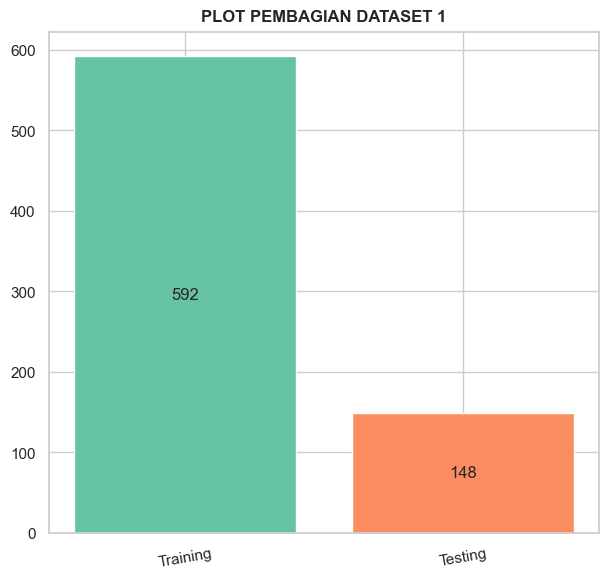

In [13]:
%matplotlib inline
# Plot Label
x_list = []
y_list = []
title_list = []
for i, (sumber, item) in enumerate(dict_split.items()):
    num_train = len(item['X_train'])
    num_test = len(item['X_test'])

    label_texts = ["Training", "Testing"]
    label_values = [num_train, num_test]
    
    title_list.extend([f"PLOT PEMBAGIAN DATASET {i + 1}"])
    x_list.append(label_texts)
    y_list.append(label_values)
myplot.bar_plot_grid(x_list=x_list, y_list=y_list, title_list=title_list)

# 4. KLASIFIKASI
___

## KLASIFIKASI MACHINE LEARNING
___

### Training Model

#### Fungsi Training

In [14]:
# =====================================================
# Fungsi: melakukan training model
# =====================================================
def training_model_ml(X, y, model_name, save_model=False, params=None):
    if params is None:
        params = {}

    model_name = model_name.lower()

    # Mapping model singkat → tuple (butuh_scaling, constructor)
    model_map = {
        "svm": (True, SVC),
        "svc": (True, SVC),
        "knn": (True, KNeighborsClassifier),
        "mlp": (True, MLPClassifier),
        "neural": (True, MLPClassifier),
        "logreg": (True, LogisticRegression),
        "logisticregression": (True, LogisticRegression),
        "rf": (False, RandomForestClassifier),
        "randomforest": (False, RandomForestClassifier),
    }

    if model_name not in model_map:
        raise ValueError(f"Model '{model_name}' tidak dikenali!")

    use_scaler, ModelClass = model_map[model_name]

    # Buat pipeline jika perlu scaling
    if use_scaler:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", ModelClass(**params))
        ])
    else:
        model = ModelClass(**params)

    model = clone(model)
    model.fit(X, y)

    # Save model
    if save_model:
        with open(save_model, "wb") as f:
            pickle.dump(model, f)

    return model

#### Proses Training

In [15]:
# Nama Model : Parameter
models_ml = {
    "SVM": {'probability': True, 'random_state':42},
    "KNN": {},
    "RandomForest": {'random_state':42},
    "LogisticRegression": {'random_state':42},
    "MLP": {'random_state':42, 'max_iter':2000}
}

In [16]:
# Mulai timer
timer = mytimer.loop_timer()
next(timer)

total_iterasi = len(models_ml) * len(dict_split)
current_iter = 0
time_list = []

# Proses Training Semua Model
for model_name, params in models_ml.items():
    for sumber, dsplit in dict_split.items():
        # Hitung waktu satu iterasi (start)
        dt = timer.send("tick")
        if dt is not None:
            time_list.append(dt)
        # update posisi iterasi
        current_iter += 1

        # =================================================================================

        # Lokasi file model yang akan disimpan
        save_model = os.path.join(PATH_FOLDER['path_model_c'], sumber, f"{model_name}.pkl")

        # Ambil dataset train
        X_train = np.array(dsplit['X_train'])
        y_train = np.array(dsplit['y_train'])

        print(f"\n[{current_iter}/{total_iterasi}] Proses Training Model\t: {model_name}")
        print(f"      Sumber Dataset\t\t: {sumber}")

        # Proses Training Model ML
        model = training_model_ml(X=X_train, 
                                  y=y_train,
                                  model_name=model_name, 
                                  save_model=save_model,
                                  params=params)
        
        # Menghitung Akurasi
        y_pred = model.predict(X_train)
        acc = accuracy_score(y_train, y_pred)


        print(f"      Akurasi\t\t\t: {acc}")
        print(f"      Model disimpan\t\t: {save_model}")
        # =================================================================================
        print(f"      Waktu iterasi\t\t: {dt:.4f} detik")

    

# Akhiri timer (ambil total waktu)
info = timer.send("done")

# Tambahkan rata-rata waktu
info["avg_time"] = sum(time_list) / len(time_list)

print("\n======================")
print("       RINGKASAN     ")
print("======================")
print(f"Total iterasi : {total_iterasi}")
print(f"Total waktu   : {info['total_time']:.4f} detik")
print(f"Rata-rata per iterasi : {info['avg_time']:.4f} detik")


[1/5] Proses Training Model	: SVM
      Sumber Dataset		: dataset_1
      Akurasi			: 0.918918918918919
      Model disimpan		: Model_C\dataset_1\SVM.pkl
      Waktu iterasi		: 0.0000 detik

[2/5] Proses Training Model	: KNN
      Sumber Dataset		: dataset_1
      Akurasi			: 0.8952702702702703
      Model disimpan		: Model_C\dataset_1\KNN.pkl
      Waktu iterasi		: 0.1386 detik

[3/5] Proses Training Model	: RandomForest
      Sumber Dataset		: dataset_1
      Akurasi			: 0.9983108108108109
      Model disimpan		: Model_C\dataset_1\RandomForest.pkl
      Waktu iterasi		: 1.6058 detik

[4/5] Proses Training Model	: LogisticRegression
      Sumber Dataset		: dataset_1
      Akurasi			: 0.9155405405405406
      Model disimpan		: Model_C\dataset_1\LogisticRegression.pkl
      Waktu iterasi		: 0.3261 detik

[5/5] Proses Training Model	: MLP
      Sumber Dataset		: dataset_1
      Akurasi			: 0.9983108108108109
      Model disimpan		: Model_C\dataset_1\MLP.pkl
      Waktu iterasi		: 0.0578

# 5. EVALUASI MODEL
___

### Fungsi Metrics Utilites

In [17]:
# ============================================================
# Fungsi Menghitung Specificity Score
# TN / (TN + FP)
# ============================================================
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


# ============================================================
# Fungsi Menghitung Seluruh Metrik Klasifikasi Utam
# Accuracy, Recall, Specificity, Precision, F1-Score, dan AUC
# ============================================================
def compute_classification_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_prob is not None:
        metrics["AUC"] = roc_auc_score(y_true, y_prob)

    return {
        "data": {
            "y_true": y_true.tolist(),
            "y_pred": y_pred.tolist(),
            "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
            "class_names": np.unique(y_true).tolist(),
        },
        "metrics": metrics,
    }

### Core Model Evaluation (ML/DL)

In [18]:
# ============================================================
# Fungsi Evaluasi performa model (ML atau DL), termasuk:
# - prediksi
# - metrik klasifikasi
# - waktu komputasi
# - penggunaan memori
# ============================================================
def evaluate_model_performance(model, X=None, y=None, test_dataset=None):
    start_time = time.perf_counter()
    tracemalloc.start()

    y_true, y_pred, y_prob = [], [], None

    # ===================== DEEP LEARNING =====================
    if test_dataset is not None:
        y_prob = []

        for images, labels in test_dataset:
            probs = model.predict(images, verbose=0).reshape(-1)
            preds = (probs >= 0.5).astype(int)

            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        y_prob = np.array(y_prob)

    # ===================== MACHINE LEARNING ==================
    else:
        y_true = np.asarray(y)
        y_pred = model.predict(X)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X)[:, 1]

    # ===================== RESOURCE USAGE ====================
    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    elapsed_time = time.perf_counter() - start_time

    results = compute_classification_metrics(y_true, y_pred, y_prob)
    results["resources"] = {
        "computational_time_sec": elapsed_time,
        "memory_footprint_MB": current_mem / (1024 ** 2),
        "memory_peak_MB": peak_mem / (1024 ** 2),
    }

    return results


### Stability Analysis (ML & DL)

In [19]:
# ============================================================
# Fungsi Menambahkan Gaussian noise ke image dataset (Deep Learning).
# ============================================================
def add_gaussian_noise_to_dataset(dataset, stddev):
    def _apply_noise(images, labels):
        noise = tf.random.normal(
            shape=tf.shape(images),
            mean=0.0,
            stddev=stddev,
            dtype=images.dtype
        )
        images_noisy = tf.clip_by_value(images + noise, 0.0, 1.0)
        return images_noisy, labels

    return dataset.map(_apply_noise, num_parallel_calls=tf.data.AUTOTUNE)


# ============================================================
# Fungsi Menghitung Stability Index model terhadap variasi Gaussian noise (ML/DL).
# ============================================================
def evaluate_stability_index(model, X=None, y=None, test_dataset=None,
                             noise_levels=(0.01, 0.03, 0.05), threshold=0.5, random_state=42,):
  
    rng = np.random.default_rng(random_state)
    scores = []

    for noise_std in noise_levels:

        # ===================== DEEP LEARNING =====================
        if test_dataset is not None:
            noisy_dataset = add_gaussian_noise_to_dataset(test_dataset, noise_std)
            y_true, y_pred = [], []

            for images, labels in noisy_dataset:
                probs = model.predict(images, verbose=0).reshape(-1)
                preds = (probs >= threshold).astype(int)
                y_true.extend(labels.numpy())
                y_pred.extend(preds)

            y_true = np.array(y_true)
            y_pred = np.array(y_pred)

        # ===================== MACHINE LEARNING ==================
        else:
            noise = rng.normal(0.0, noise_std, X.shape)
            X_noisy = X + noise
            y_true = np.asarray(y)
            y_pred = model.predict(X_noisy)

        score = accuracy_score(y_true, y_pred)
        scores.append(score)

    scores = np.array(scores)
    stability_index = 1.0 - (scores.std() / (scores.mean() + 1e-8))

    return {
        "noise_levels": list(noise_levels),
        "scores": scores.tolist(),
        "stability_index": float(stability_index),
        "metric_used": "Accuracy",
    }


### Pipeline Evaluation (Multi-Model)

In [20]:
# ============================================================
# Pipeline evaluasi banyak model (ML atau DL).
# ============================================================
def run_evaluation_pipeline(model_names, model_dir, dataset_name,
                            X=None, y=None, test_dataset=None,
                            current_iter=0, total_iter=1, elapsed_dt=0.0, results_store=None):
    if results_store is None:
        results_store = {}

    is_dl = test_dataset is not None
    # Tipe model berdasarkan extension file
    model_type = "Deep Learning" if is_dl else "Machine Learning"
    model_ext = ".keras" if is_dl else ".pkl"

    print(f"\n--- Evaluasi {model_type} | Dataset: {dataset_name} ---")
    # 
    for model_name in model_names:
        current_iter += 1
        # Lokasi Model
        model_path = os.path.join(model_dir, f"{model_name}{model_ext}")
        # Lokasi History Model
        history_path = os.path.join(model_dir, f"history_{model_name}.pkl")

        if not os.path.exists(model_path):
            print(f"[{current_iter}/{total_iter}] {model_name} → SKIP")
            continue

        print(f"[{current_iter}/{total_iter}] {model_name} → Evaluating")

        # Load model
        model = (tf.keras.models.load_model(model_path) if is_dl else pickle.load(open(model_path, "rb")))

        # Core evaluation
        metrics = evaluate_model_performance(model, X=X, y=y, test_dataset=test_dataset)

        # Stability analysis
        metrics["stability"] = evaluate_stability_index(model, X=X, y=y, test_dataset=test_dataset)

        # Model size
        metrics["resources"]["model_size_MB"] = (os.path.getsize(model_path) / (1024 ** 2))

        # Training history (DL)
        if os.path.exists(history_path):
            with open(history_path, "rb") as f:
                metrics["history_train"] = pickle.load(f)
        else:
            metrics["history_train"] = None

        # example = {dataset_1_SVM: 
        results_store[f"{dataset_name}_{model_name}"] = metrics

        print(f"\tAccuracy : {metrics['metrics']['Accuracy']:.4f}")
        print(f"\tTime     : {metrics['resources']['computational_time_sec']:.4f} s")

    return current_iter, results_store

## Proses Evaluasi Model

In [21]:
models_ml = ["SVM", "KNN", "RandomForest", "LogisticRegression", "MLP"]

results = {}
current_iter = 0

for dataset_name, split in dict_split.items():
    X_test = np.array(split["X_test"])
    y_test = np.array(split["y_test"])

    model_path = os.path.join(PATH_FOLDER["path_model_c"], dataset_name)

    # ============== Machine Learning ==============
    current_iter, results = run_evaluation_pipeline(
        model_names=models_ml,
        model_dir=model_path,
        dataset_name=dataset_name,
        X=X_test,
        y=y_test,
        current_iter=current_iter,
        total_iter=len(models_ml),
        results_store=results,
    )



--- Evaluasi Machine Learning | Dataset: dataset_1 ---
[1/5] SVM → Evaluating
	Accuracy : 0.8378
	Time     : 0.0209 s
[2/5] KNN → Evaluating
	Accuracy : 0.8446
	Time     : 0.0149 s
[3/5] RandomForest → Evaluating
	Accuracy : 0.8649
	Time     : 0.1858 s
[4/5] LogisticRegression → Evaluating
	Accuracy : 0.8649
	Time     : 0.0030 s
[5/5] MLP → Evaluating
	Accuracy : 0.8581
	Time     : 0.0050 s


In [22]:
# Simpan hasil akhir ke json
with open('skenario_C_final.json', "w") as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

## Visualisasi

In [23]:
with open('skenario_C_final.json', 'r') as f:
    results = json.load(f)

In [24]:
%matplotlib inline
# ============================================================
# Fungsi Visualisasi Evaluasi Model
# ============================================================
def visualisasi(dict_results, list_sumber, display):
    for sumber in list_sumber:

        # Struktur penampung data
        history_cnn  = {'history_list': [], 'titles': []}
        conf_matrix  = {'conf_matrices': [], 'titles': [], 'class_names': None}
        eval_metrics = {'metrics_list': [], 'titles': []}
        comput_time = {'results': [], 'titles': []}
        rss_usage = {'results': [], 'titles': []}
        stability_result = {'results':[], 'titles':[]}

        # Filter semua model berdasarkan sumber
        model_keys = [k for k in dict_results if k.startswith(sumber)]

        for key in model_keys:
            result = dict_results[key]
            model_name = key.split(f"{sumber}_", 1)[1]

            # -------------------------------------------------------
            # HISTORY TRAINING CNN
            # -------------------------------------------------------
            history_dict = result.get("history_train")
            if history_dict:
                history_cnn['history_list'].append(dict(history_dict))
                history_cnn['titles'].append(f"History Training {model_name} - {sumber}")

            # -------------------------------------------------------
            # CONFUSION MATRIX
            # -------------------------------------------------------
            data_block = result.get("data")
            if data_block:
                cm          = data_block.get("confusion_matrix")
                class_names = data_block.get("class_names")

                if cm is not None:
                    conf_matrix['conf_matrices'].append(cm)
                    conf_matrix['titles'].append(model_name)
                    conf_matrix['class_names'] = class_names

            # -------------------------------------------------------
            # EVALUASI METRIK MODEL
            # -------------------------------------------------------
            metrics = result.get("metrics")
            if metrics:
                eval_metrics['metrics_list'].append(dict(metrics))
                eval_metrics['titles'].append(model_name)

            resources = result.get("resources")
            if resources:
                # -------------------------------------------------------
                # Computational Time
                # -------------------------------------------------------
                comput_time['results'].append(resources)
                comput_time['titles'].append(model_name)
                # -------------------------------------------------------
                # Resource Usage Comparison
                # -------------------------------------------------------
                rss_usage['results'].append(resources)
                rss_usage['titles'].append(model_name)
            # -------------------------------------------------------
            # Stability Index
            # -------------------------------------------------------
            stability = result.get("stability")
            if stability:
                stability_result['results'].append(stability) 
                stability_result['titles'].append(model_name)


        # =======================================================
        # TAMPILKAN SEMUA VISUALISASI SESUAI REQUEST
        # =======================================================
        if "history_cnn" in display:
            myplot.plot_history_cnn_grid(**history_cnn)

        if "confusion_matrix" in display:
            myplot.plot_confusion_matrices_grid(
                **conf_matrix,
                main_title=f"Confusion Matrix | {sumber}",
                max_cols=max(1, len(conf_matrix['conf_matrices']) // 2),
                save_as=os.path.join(PATH_FOLDER['path_plot'], "confusion_matrix_C.png")
            )

        if "evaluate_models" in display:
            myplot.plot_classification_metrics_bar(
                **eval_metrics,
                main_title=f"Model Evaluation Metrics | {sumber}",
                save_as=os.path.join(PATH_FOLDER['path_plot'], "evaluate_models_C.png")
            )
            
        if "computational_time" in display:
            myplot.plot_computational_time(
                **comput_time,
                main_title=f"Computational Time | {sumber}",
                save_as=os.path.join(PATH_FOLDER['path_plot'], "computational_time_C.png")
            )

        if 'resource_usage' in display:
            myplot.plot_resource_usage(
                **rss_usage,
                main_title=f"Resource Usage Comparison | {sumber}",
                save_as=os.path.join(PATH_FOLDER['path_plot'], "resource_usage_C.png")
            )
            
        if 'stability_index' in display:
            myplot.plot_stability_index(
                **stability_result,
                main_title=f"Stability Index Comparison | {sumber}",
                save_as=os.path.join(PATH_FOLDER['path_plot'], "stability_index_C.png")
            )

### Visualisasi History Training CNN

In [25]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['history_cnn'])

### Visualisasi Confusion Matrix

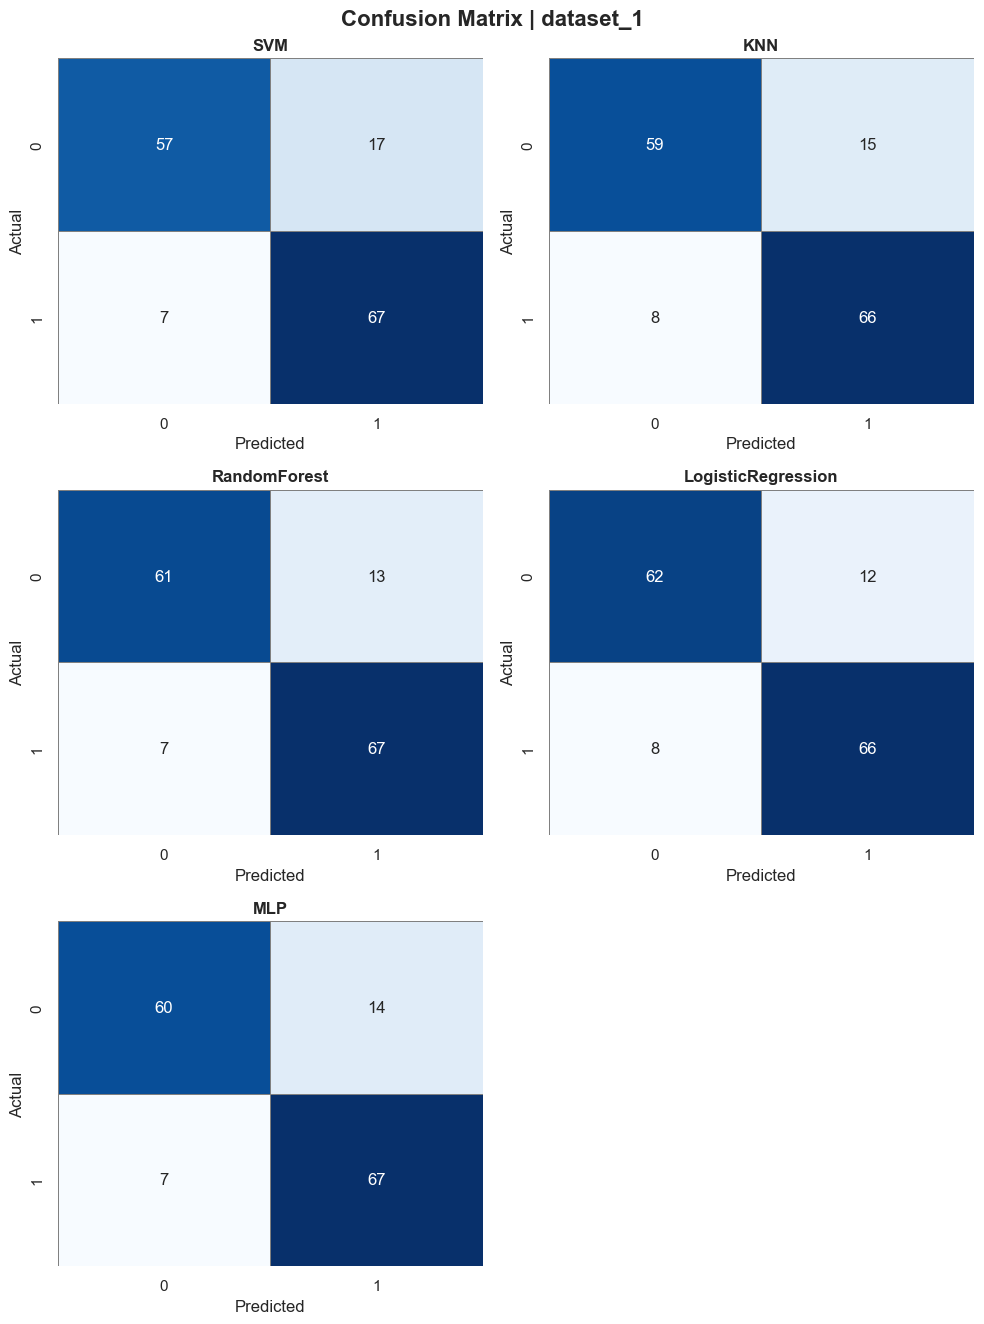

In [26]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['confusion_matrix'])

### Visualisasi Evaluasi Model

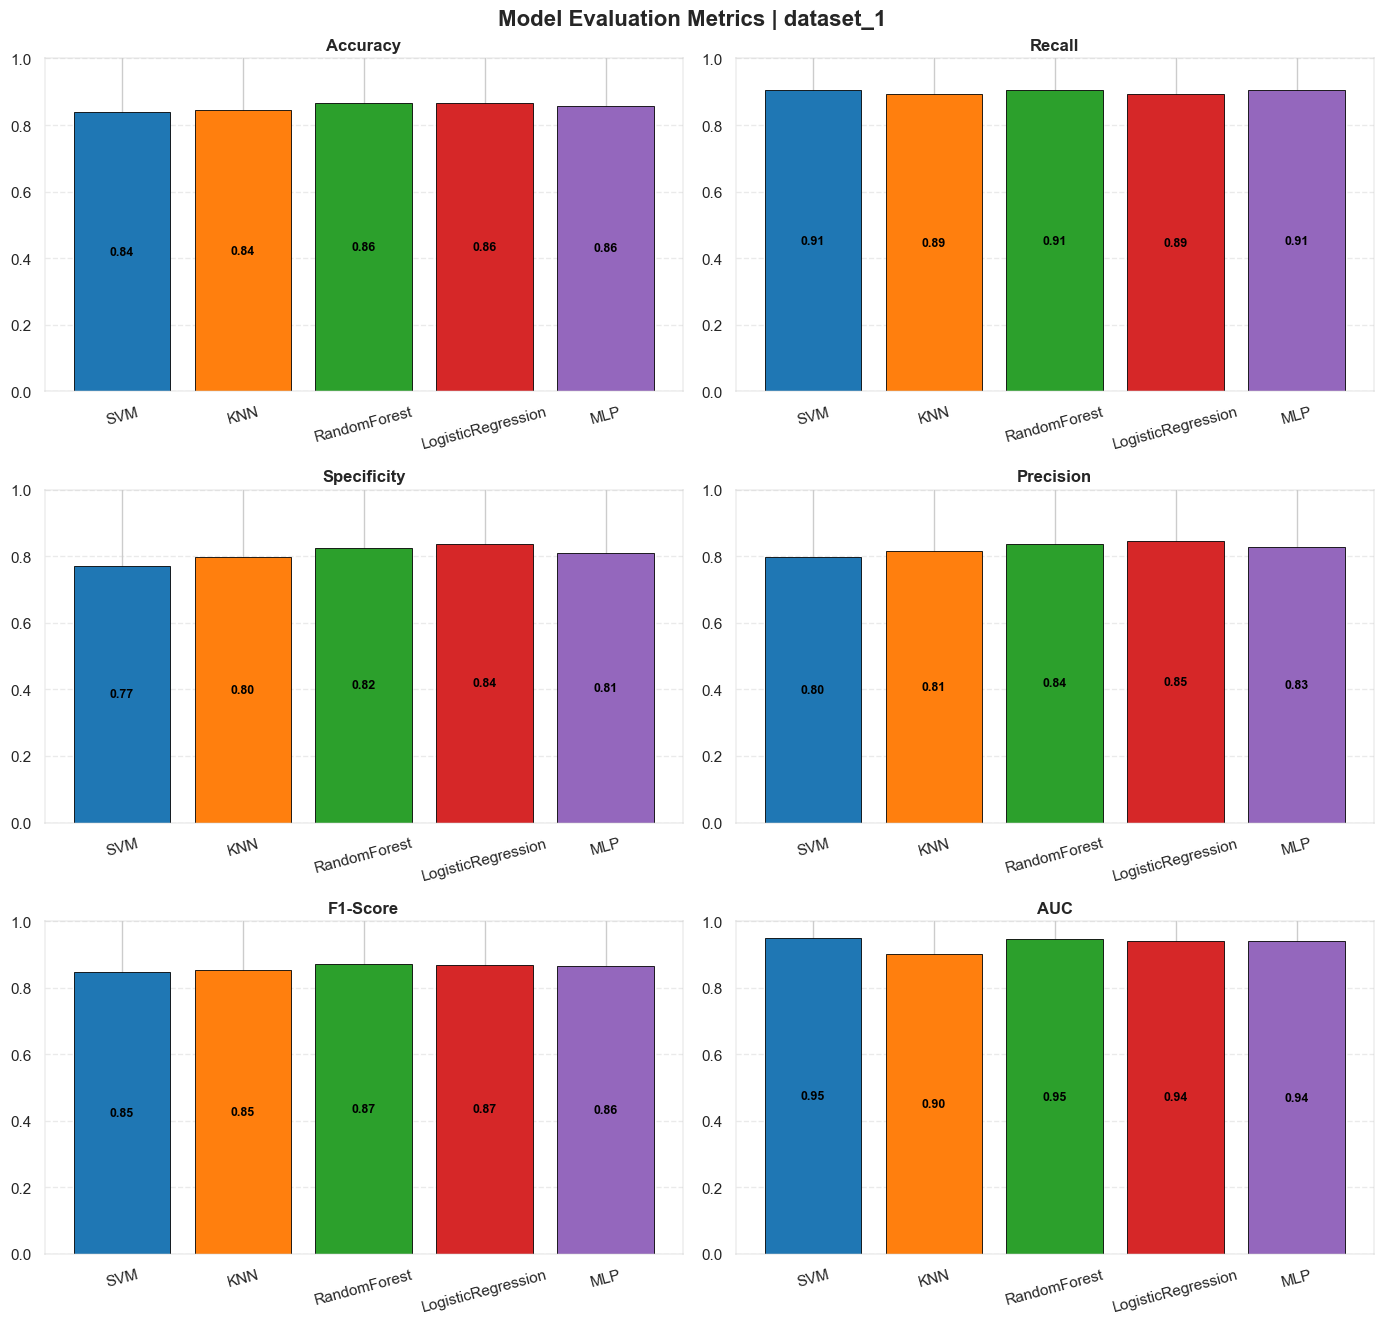

In [27]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['evaluate_models'])

### Visualisasi Computational Time

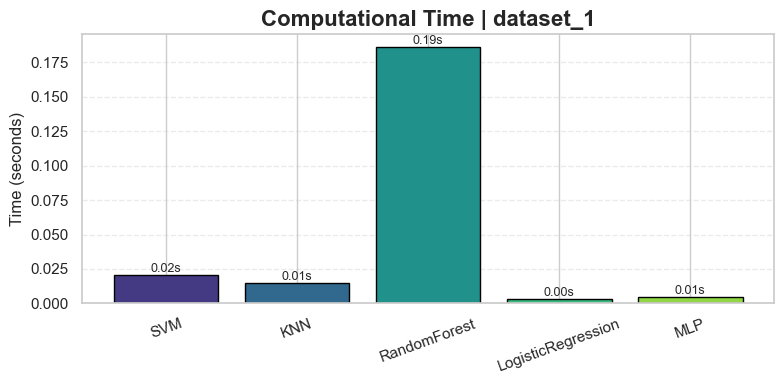

In [28]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['computational_time'])

### Visualisasi Resource Usage

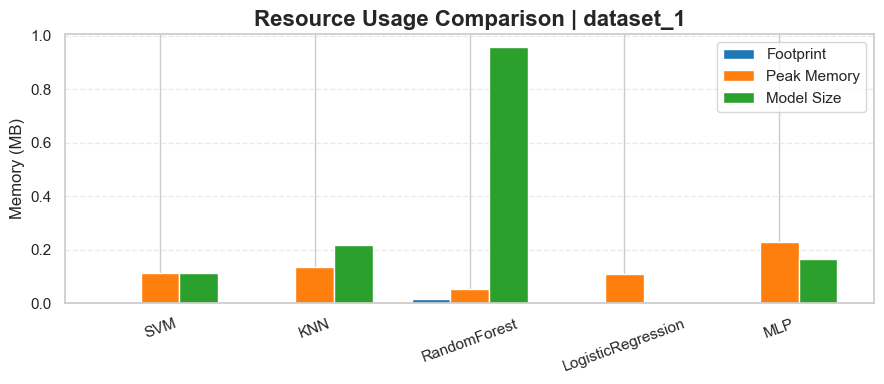

In [29]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['resource_usage'])

### Visualisasi Stability Index

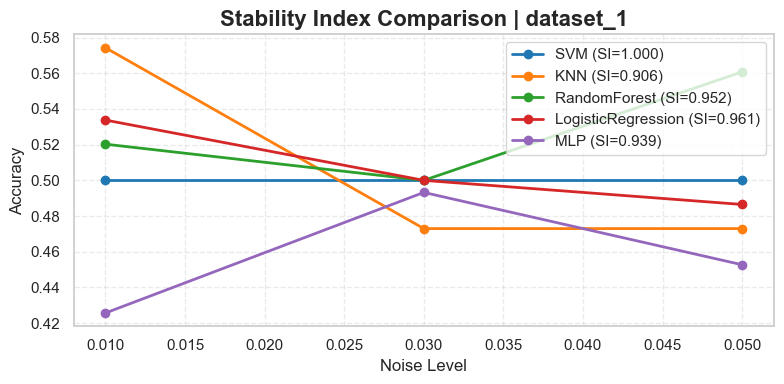

In [30]:
visualisasi(dict_results=results, list_sumber=list(dict_split.keys()), display=['stability_index'])